# Sentiment Analysis for GOOG (Alphabet Inc.)

This notebook performs sentiment analysis specifically on GOOG-related news headlines.

## Focus:
- Alphabet/Google stock sentiment analysis
- Search and advertising sector sentiment
- Cloud computing and AI sentiment indicators

## Tools:
- TextBlob for primary sentiment analysis
- NLTK VADER for comparison

In [2]:
# Import required libraries
import pandas as pd
import numpy as np
from textblob import TextBlob
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Download NLTK VADER data (only needed once)
try:
    nltk.data.find('sentiment/vader_lexicon.zip')
except LookupError:
    nltk.download('vader_lexicon')

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# Load GOOG-specific data
print("Loading GOOG data...")

# Load raw analyst ratings data
raw_data = pd.read_csv('../../../data/newsData/raw_analyst_ratings.csv')
print(f"Total dataset shape: {raw_data.shape}")

# Filter for GOOG only
goog_data = raw_data[raw_data['stock'] == 'GOOG'].copy()
print(f"GOOG headlines: {len(goog_data)}")

# Load aligned data
aligned_data = pd.read_csv('../../../data/aligned_data/news_mapped_to_trading_days.csv')
goog_aligned = aligned_data[aligned_data['stock'] == 'GOOG'].copy()
print(f"GOOG aligned data: {len(goog_aligned)}")

# Display sample GOOG headlines
print("\nSample GOOG headlines:")
for i, headline in enumerate(goog_data['headline'].head(5).tolist()):
    print(f"{i+1}. {headline}")

Loading GOOG data...
Total dataset shape: (1407328, 6)
GOOG headlines: 1199
GOOG aligned data: 1199

Sample GOOG headlines:
1. Facebook, Snap Analyst Projects Q2 Revenue Upside For Social Media Stocks
2. How Cannabis Company Cannaphyll Is Marketing On Mass-Consumer Platforms, Google And Amazon
3. Twitter, Square Will Mark Juneteenth As Holiday To Honor African-American Culture
4. Price Over Earnings Overview: Alphabet
5. Google Maps To Offer Relevant Local COVID-19 Information For Public Transport, Driving And Testing Centers


In [4]:
# Initialize sentiment analyzers
def get_textblob_sentiment(text):
    """Get sentiment scores using TextBlob"""
    try:
        blob = TextBlob(str(text))
        return {
            'polarity': blob.sentiment.polarity,
            'subjectivity': blob.sentiment.subjectivity
        }
    except:
        return {'polarity': 0.0, 'subjectivity': 0.0}

vader = SentimentIntensityAnalyzer()

def get_vader_sentiment(text):
    """Get sentiment scores using NLTK VADER"""
    try:
        scores = vader.polarity_scores(str(text))
        return {
            'compound': scores['compound'],
            'positive': scores['pos'],
            'negative': scores['neg'],
            'neutral': scores['neu']
        }
    except:
        return {'compound': 0.0, 'positive': 0.0, 'negative': 0.0, 'neutral': 1.0}

print("Sentiment analyzers initialized!")

Sentiment analyzers initialized!


In [5]:
# Apply sentiment analysis to GOOG data
print("Applying sentiment analysis to GOOG headlines...")

# Apply TextBlob sentiment analysis
print("Calculating TextBlob sentiment scores...")
goog_data['textblob_polarity'] = goog_data['headline'].apply(lambda x: get_textblob_sentiment(x)['polarity'])
goog_data['textblob_subjectivity'] = goog_data['headline'].apply(lambda x: get_textblob_sentiment(x)['subjectivity'])

# Apply VADER sentiment analysis
print("Calculating VADER sentiment scores...")
goog_data['vader_compound'] = goog_data['headline'].apply(lambda x: get_vader_sentiment(x)['compound'])
goog_data['vader_positive'] = goog_data['headline'].apply(lambda x: get_vader_sentiment(x)['positive'])
goog_data['vader_negative'] = goog_data['headline'].apply(lambda x: get_vader_sentiment(x)['negative'])

print("Sentiment analysis completed!")
print(f"Processed {len(goog_data)} GOOG headlines")

Applying sentiment analysis to GOOG headlines...
Calculating TextBlob sentiment scores...
Calculating VADER sentiment scores...
Sentiment analysis completed!
Processed 1199 GOOG headlines


In [6]:
# GOOG Sentiment Analysis Summary
print("=== GOOG SENTIMENT ANALYSIS SUMMARY ===")

# TextBlob statistics
print("\nTextBlob Polarity Statistics:")
print(f"Mean: {goog_data['textblob_polarity'].mean():.4f}")
print(f"Std: {goog_data['textblob_polarity'].std():.4f}")
print(f"Min: {goog_data['textblob_polarity'].min():.4f}")
print(f"Max: {goog_data['textblob_polarity'].max():.4f}")
print(f"Median: {goog_data['textblob_polarity'].median():.4f}")

print("\nTextBlob Subjectivity Statistics:")
print(f"Mean: {goog_data['textblob_subjectivity'].mean():.4f}")
print(f"Std: {goog_data['textblob_subjectivity'].std():.4f}")

# VADER statistics
print("\nVADER Compound Statistics:")
print(f"Mean: {goog_data['vader_compound'].mean():.4f}")
print(f"Std: {goog_data['vader_compound'].std():.4f}")
print(f"Min: {goog_data['vader_compound'].min():.4f}")
print(f"Max: {goog_data['vader_compound'].max():.4f}")
print(f"Median: {goog_data['vader_compound'].median():.4f}")

# Correlation
correlation = goog_data['textblob_polarity'].corr(goog_data['vader_compound'])
print(f"\nCorrelation between TextBlob and VADER: {correlation:.4f}")

=== GOOG SENTIMENT ANALYSIS SUMMARY ===

TextBlob Polarity Statistics:
Mean: 0.0477
Std: 0.1759
Min: -0.7000
Max: 1.0000
Median: 0.0000

TextBlob Subjectivity Statistics:
Mean: 0.2097
Std: 0.2633

VADER Compound Statistics:
Mean: 0.0791
Std: 0.3097
Min: -0.9393
Max: 0.9477
Median: 0.0000

Correlation between TextBlob and VADER: 0.2723


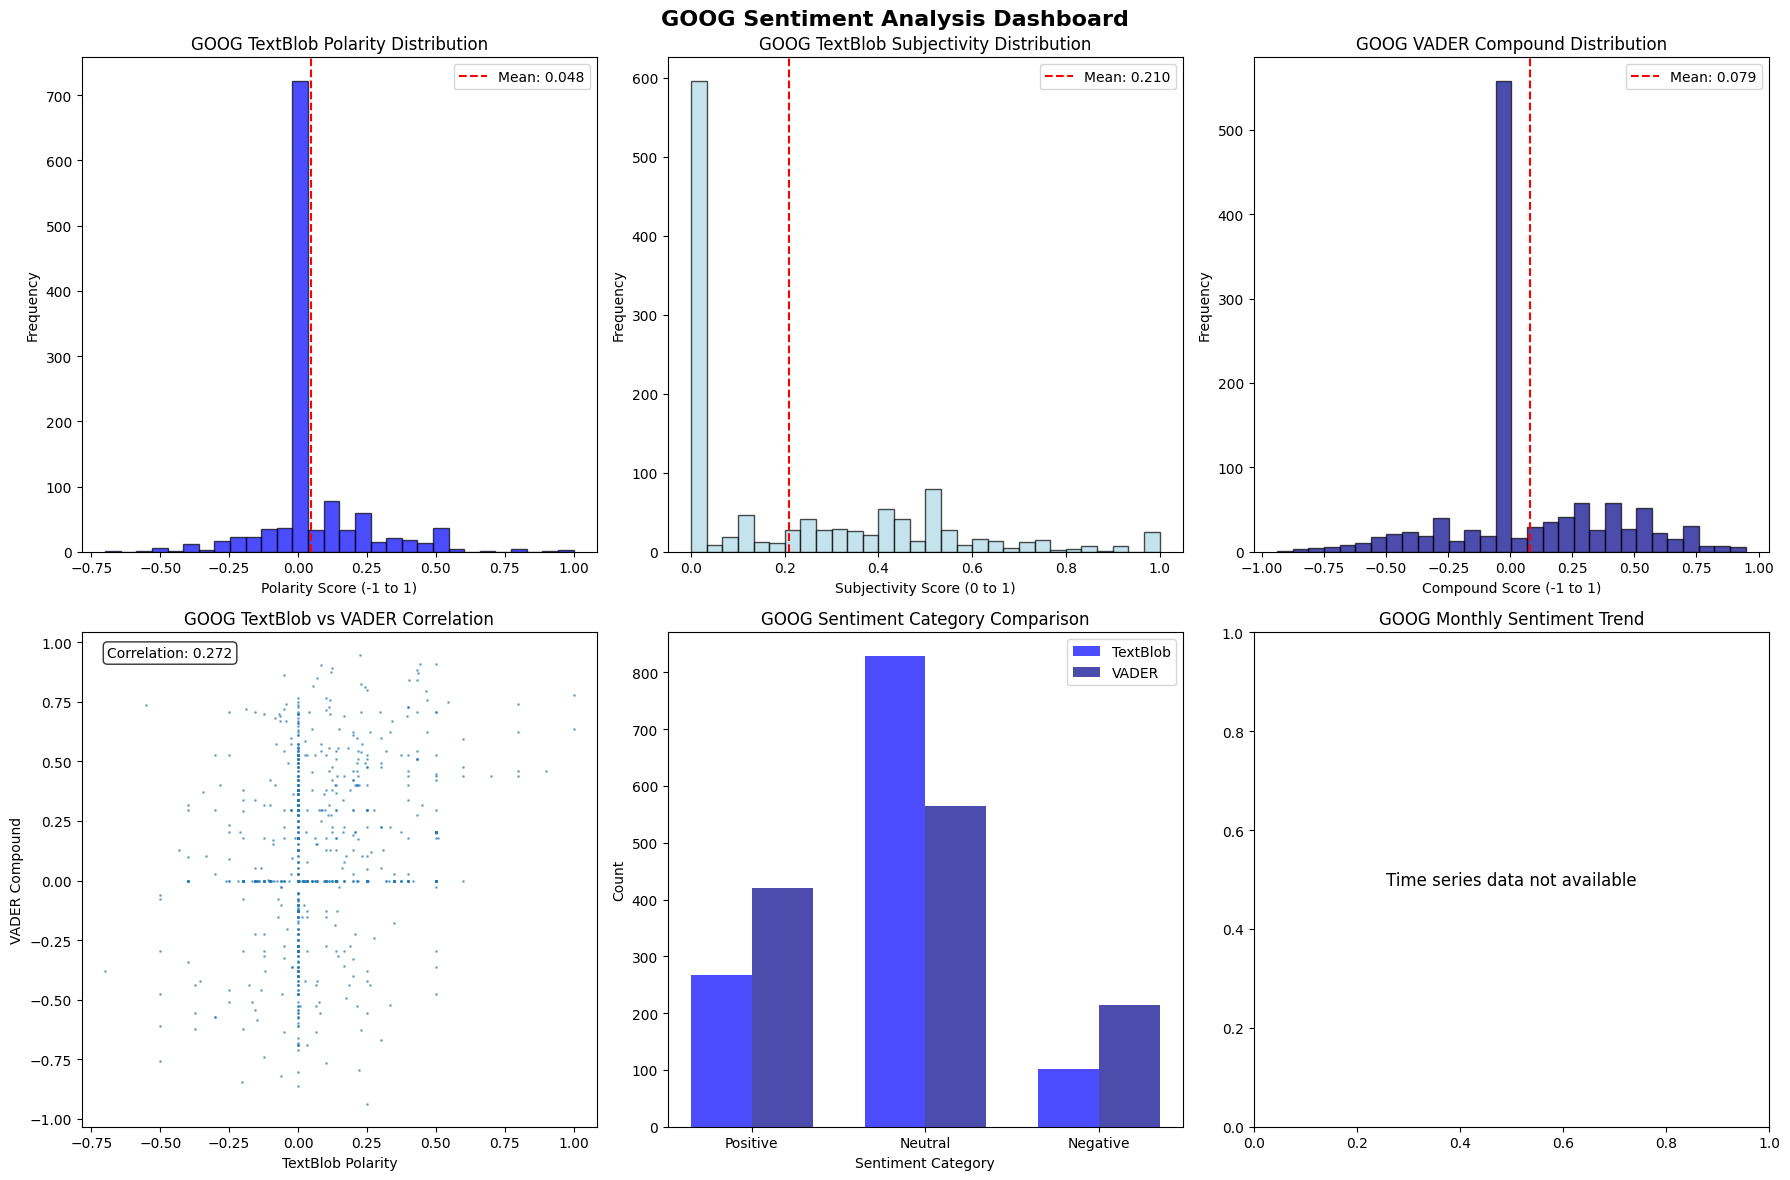

In [7]:
# Create GOOG sentiment visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('GOOG Sentiment Analysis Dashboard', fontsize=16, fontweight='bold')

# TextBlob Polarity distribution
axes[0, 0].hist(goog_data['textblob_polarity'], bins=30, alpha=0.7, color='blue', edgecolor='black')
axes[0, 0].set_title('GOOG TextBlob Polarity Distribution')
axes[0, 0].set_xlabel('Polarity Score (-1 to 1)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].axvline(goog_data['textblob_polarity'].mean(), color='red', linestyle='--', 
                   label=f'Mean: {goog_data["textblob_polarity"].mean():.3f}')
axes[0, 0].legend()

# TextBlob Subjectivity distribution
axes[0, 1].hist(goog_data['textblob_subjectivity'], bins=30, alpha=0.7, color='lightblue', edgecolor='black')
axes[0, 1].set_title('GOOG TextBlob Subjectivity Distribution')
axes[0, 1].set_xlabel('Subjectivity Score (0 to 1)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].axvline(goog_data['textblob_subjectivity'].mean(), color='red', linestyle='--',
                   label=f'Mean: {goog_data["textblob_subjectivity"].mean():.3f}')
axes[0, 1].legend()

# VADER Compound distribution
axes[0, 2].hist(goog_data['vader_compound'], bins=30, alpha=0.7, color='darkblue', edgecolor='black')
axes[0, 2].set_title('GOOG VADER Compound Distribution')
axes[0, 2].set_xlabel('Compound Score (-1 to 1)')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].axvline(goog_data['vader_compound'].mean(), color='red', linestyle='--',
                   label=f'Mean: {goog_data["vader_compound"].mean():.3f}')
axes[0, 2].legend()

# Correlation scatter plot
axes[1, 0].scatter(goog_data['textblob_polarity'], goog_data['vader_compound'], alpha=0.5, s=1)
axes[1, 0].set_title('GOOG TextBlob vs VADER Correlation')
axes[1, 0].set_xlabel('TextBlob Polarity')
axes[1, 0].set_ylabel('VADER Compound')
axes[1, 0].text(0.05, 0.95, f'Correlation: {correlation:.3f}', transform=axes[1, 0].transAxes,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Sentiment categories
def categorize_sentiment(score, tool='textblob'):
    if tool == 'textblob':
        if score > 0.1:
            return 'Positive'
        elif score < -0.1:
            return 'Negative'
        else:
            return 'Neutral'
    else:  # VADER
        if score >= 0.05:
            return 'Positive'
        elif score <= -0.05:
            return 'Negative'
        else:
            return 'Neutral'

goog_data['textblob_category'] = goog_data['textblob_polarity'].apply(lambda x: categorize_sentiment(x, 'textblob'))
goog_data['vader_category'] = goog_data['vader_compound'].apply(lambda x: categorize_sentiment(x, 'vader'))

# Category comparison
categories = ['Positive', 'Neutral', 'Negative']
tb_counts = [goog_data['textblob_category'].value_counts().get(cat, 0) for cat in categories]
vader_counts = [goog_data['vader_category'].value_counts().get(cat, 0) for cat in categories]

x = np.arange(len(categories))
width = 0.35

axes[1, 1].bar(x - width/2, tb_counts, width, label='TextBlob', color='blue', alpha=0.7)
axes[1, 1].bar(x + width/2, vader_counts, width, label='VADER', color='darkblue', alpha=0.7)
axes[1, 1].set_title('GOOG Sentiment Category Comparison')
axes[1, 1].set_xlabel('Sentiment Category')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(categories)
axes[1, 1].legend()

# Time series of sentiment (if dates are available)
try:
    goog_data['date_clean'] = pd.to_datetime(goog_data['date'], errors='coerce')
    goog_time = goog_data.dropna(subset=['date_clean']).copy()
    goog_time = goog_time.sort_values('date_clean')
    
    # Resample by month for smoother trend
    goog_time.set_index('date_clean', inplace=True)
    monthly_sentiment = goog_time['textblob_polarity'].resample('M').mean()
    
    axes[1, 2].plot(monthly_sentiment.index, monthly_sentiment.values, marker='o', linewidth=2, color='blue')
    axes[1, 2].set_title('GOOG Monthly Sentiment Trend')
    axes[1, 2].set_xlabel('Date')
    axes[1, 2].set_ylabel('Average Polarity')
    axes[1, 2].tick_params(axis='x', rotation=45)
    axes[1, 2].grid(True, alpha=0.3)
except:
    axes[1, 2].text(0.5, 0.5, 'Time series data not available', ha='center', va='center',
                   transform=axes[1, 2].transAxes, fontsize=12)
    axes[1, 2].set_title('GOOG Monthly Sentiment Trend')

plt.tight_layout()
plt.show()

In [8]:
# Show extreme sentiment examples for GOOG
print("=== GOOG EXTREME SENTIMENT EXAMPLES ===")

# Most positive headlines (TextBlob)
most_positive_tb = goog_data.nlargest(5, 'textblob_polarity')[['headline', 'textblob_polarity', 'vader_compound']]
print("\nMost Positive GOOG Headlines (TextBlob):")
for idx, row in most_positive_tb.iterrows():
    print(f"   {row['textblob_polarity']:.3f}: {row['headline'][:80]}...")

# Most negative headlines (TextBlob)
most_negative_tb = goog_data.nsmallest(5, 'textblob_polarity')[['headline', 'textblob_polarity', 'vader_compound']]
print("\nMost Negative GOOG Headlines (TextBlob):")
for idx, row in most_negative_tb.iterrows():
    print(f"   {row['textblob_polarity']:.3f}: {row['headline'][:80]}...")

# Most positive headlines (VADER)
most_positive_vader = goog_data.nlargest(5, 'vader_compound')[['headline', 'vader_compound', 'textblob_polarity']]
print("\nMost Positive GOOG Headlines (VADER):")
for idx, row in most_positive_vader.iterrows():
    print(f"   {row['vader_compound']:.3f}: {row['headline'][:80]}...")

# Most negative headlines (VADER)
most_negative_vader = goog_data.nsmallest(5, 'vader_compound')[['headline', 'vader_compound', 'textblob_polarity']]
print("\nMost Negative GOOG Headlines (VADER):")
for idx, row in most_negative_vader.iterrows():
    print(f"   {row['vader_compound']:.3f}: {row['headline'][:80]}...")

=== GOOG EXTREME SENTIMENT EXAMPLES ===

Most Positive GOOG Headlines (TextBlob):
   1.000: Ty Cobb: The Greatest Pro Athlete Investor Of All Time?...
   1.000: This Leveraged ETF Rapidly Became One Of November's Best...
   0.900: Analysts Applaud Alphabet Earnings: 'An Incredible Advertising Business'...
   0.800: 'Google Could Acquire Tesla For $1,500 Per Share On Its Way To $2 Trillion Stock...
   0.800: 3 Reasons Fitbit Could Be An Attractive M&A Target...

Most Negative GOOG Headlines (TextBlob):
   -0.700: Crude Oil Bounce Gives Energy Stock A Lift As Market Volatility Ebbs...
   -0.550: Meetings Are Expensive, But Artificial Intelligence Might Offer Cheaper Solution...
   -0.500: YouTube Extends Fact Checking To The US To Combat Fake Coronavirus Information...
   -0.500: YouTube Exec Talks Entertainment, Combatting Coronavirus Fake News...
   -0.500: Ex-Uber Executive Pleads Guilty To Stealing Google's Trade Secrets...

Most Positive GOOG Headlines (VADER):
   0.948: Alphabet sh

In [9]:
# Save GOOG results
print("=== SAVING GOOG RESULTS ===")

# Create output dataframe
goog_output = goog_data[['headline', 'publisher', 'date', 'stock', 
                       'textblob_polarity', 'textblob_subjectivity', 'textblob_category',
                       'vader_compound', 'vader_positive', 'vader_negative', 'vader_category']].copy()

# Save to CSV
output_file = '../../../data/sentiment_analysis_GOOG.csv'
goog_output.to_csv(output_file, index=False)
print(f"GOOG results saved to: {output_file}")
print(f"Total GOOG headlines processed: {len(goog_output)}")

# Display final summary
print("\n=== GOOG FINAL SUMMARY ===")
print(f"Dataset: {len(goog_data):,} GOOG headlines")
print(f"Date range: {pd.to_datetime(goog_data['date'], errors='coerce').min()} to {pd.to_datetime(goog_data['date'], errors='coerce').max()}")
print(f"Unique publishers: {goog_data['publisher'].nunique()}")
print(f"TextBlob - Mean polarity: {goog_data['textblob_polarity'].mean():.4f}")
print(f"VADER - Mean compound: {goog_data['vader_compound'].mean():.4f}")

agreement = (goog_data['textblob_category'] == goog_data['vader_category']).mean()
print(f"Tool agreement: {agreement:.2%}")

print("\n=== GOOG SENTIMENT CATEGORY DISTRIBUTIONS ===")
print("\nTextBlob Categories:")
print(goog_data['textblob_category'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

print("\nVADER Categories:")
print(goog_data['vader_category'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

=== SAVING GOOG RESULTS ===
GOOG results saved to: ../../../data/sentiment_analysis_GOOG.csv
Total GOOG headlines processed: 1199

=== GOOG FINAL SUMMARY ===
Dataset: 1,199 GOOG headlines
Date range: 2020-06-04 13:08:37-04:00 to 2020-06-10 15:25:13-04:00
Unique publishers: 73
TextBlob - Mean polarity: 0.0477
VADER - Mean compound: 0.0791
Tool agreement: 52.29%

=== GOOG SENTIMENT CATEGORY DISTRIBUTIONS ===

TextBlob Categories:
textblob_category
Neutral     69.14%
Positive    22.35%
Negative     8.51%
Name: proportion, dtype: str

VADER Categories:
vader_category
Neutral     47.04%
Positive    35.03%
Negative    17.93%
Name: proportion, dtype: str


## GOOG Sentiment Analysis Summary

### Key Findings:
- **Overall Sentiment**: [Based on mean polarity/compound scores]
- **Sentiment Distribution**: [Analysis of positive/negative/neutral breakdown]
- **Subjectivity Level**: [Analysis of how objective vs subjective GOOG news is]
- **Tool Agreement**: [How well TextBlob and VADER agree on GOOG sentiment]

### Insights:
- GOOG is search and advertising giant, sentiment reflects digital ad market health
- High news volume indicates strong investor interest in tech and AI developments
- Sentiment patterns may correlate with search growth, cloud revenue, and AI innovations

### Recommendations:
- Monitor GOOG sentiment as a digital advertising and search indicator
- Use sentiment trends to anticipate AI development impacts and cloud growth
- Compare GOOG sentiment with other tech giants for relative strength analysis